In [15]:
import os
import re
import random
import pickle
import numpy as np
import torch
import torch.nn as nn
import matplotlib
import matplotlib.pyplot as plt

# 경로
BASE_DIR = os.path.abspath('')
DATA_DIR = os.path.join(BASE_DIR, 'data')
W2V_PATH = os.path.join(DATA_DIR, 'ko', 'ko.bin')   # 사전학습 한국어 Word2Vec

# 재현성
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# 디바이스
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 그래프 한글 깨짐 방지
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

print('device :', device, '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')
print('data   :', DATA_DIR)

device : cuda | NVIDIA GeForce RTX 5070 Ti Laptop GPU
data   : C:\Aiffel\AIFFEL_quest_rs\Exploration\Ex06\data


# 프로젝트 : 네이버 영화리뷰 감성분석 도전하기

이전 스텝까지는 영문 텍스트의 감정 분석을 진행해 보았습니다. 그렇다면 이번에는 한국어 텍스트의 감정 분석을 진행해 보면 어떨까요? 오늘 활용할 데이터셋은 네이버 영화의 댓글을 모아 구성된 [Naver sentiment movie corpus](https://github.com/e9t/nsmc)입니다.

In [6]:
# 데이터 다운로드
import urllib.request

NSMC_URL = 'https://raw.githubusercontent.com/e9t/nsmc/master/'
os.makedirs(DATA_DIR, exist_ok=True)

for fname in ['ratings_train.txt', 'ratings_test.txt']:
    fpath = os.path.join(DATA_DIR, fname)
    if not os.path.exists(fpath):
        print(f'{fname} 다운로드 중...')
        urllib.request.urlretrieve(NSMC_URL + fname, fpath)
    print(f'{fname:20s} OK ({os.path.getsize(fpath)/1024**2:5.1f} MB)')

print(f'{"ko.bin (Word2Vec)":20s} {"OK" if os.path.exists(W2V_PATH) else "없음 -> 8) 섹션 전에 준비 필요"}')

ratings_train.txt    OK ( 14.0 MB)
ratings_test.txt     OK (  4.7 MB)
ko.bin (Word2Vec)    OK


## 라이브러리 버전을 확인해 봅니다
---
사용할 라이브러리 버전을 둘러봅시다.

In [7]:
import pandas
import konlpy
import gensim

print('pandas    :', pandas.__version__)
print('konlpy    :', konlpy.__version__)
print('gensim    :', gensim.__version__)
print('torch     :', torch.__version__)
print('cuda      :', torch.version.cuda, '| available:', torch.cuda.is_available())

pandas    : 3.0.5
konlpy    : 0.6.0
gensim    : 4.3.2
torch     : 2.11.0+cu128
cuda      : 12.8 | available: True


## 1) 데이터 준비와 확인
---

In [8]:
import pandas as pd

# 데이터를 읽어봅시다.
train_data = pd.read_table(os.path.join(DATA_DIR, 'ratings_train.txt'))
test_data = pd.read_table(os.path.join(DATA_DIR, 'ratings_test.txt'))

print('train :', train_data.shape, '| test :', test_data.shape)
train_data.head()

train : (150000, 3) | test : (50000, 3)


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


## 2) 데이터로더 구성
---
실습 때 다루었던 IMDB 데이터셋은 텍스트를 가공하여 `imdb.data_loader()` 메서드를 호출하면 숫자 인덱스로 변환된 텍스트와 `word_to_index` 딕셔너리까지 친절하게 제공합니다. 그러나 이번에 다루게 될 nsmc 데이터셋은 전혀 가공되지 않은 텍스트 파일로 이루어져 있습니다. 이것을 읽어서 `imdb.data_loader()`와 동일하게 동작하는 자신만의 `data_loader`를 만들어 보는 것으로 시작합니다. `data_loader` 안에서는 다음을 수행해야 합니다.

- 데이터의 중복 제거
- NaN 결측치 제거
- 한국어 토크나이저로 토큰화
- 불용어(Stopwords) 제거
- 사전`word_to_index` 구성
- 텍스트 스트링을 사전 인덱스 스트링으로 변환
- `X_train`, `y_train`, `X_test`, `y_test`, `word_to_index` 리턴

In [9]:
# 토크나이저: okt 사용
from konlpy.tag import Okt
from collections import Counter

tokenizer = Okt()
stopwords = ['의','가','이','은','들','는','좀','잘','걍','과','도','를','으로','자','에','와','한','하다']

def tokenize(sentence):
    """정제 -> 형태소 분석 -> 불용어 제거"""
    sentence = re.sub(r'[^0-9a-zA-Zㄱ-ㅎㅏ-ㅣ가-힣\s]', ' ', str(sentence))
    morphs = tokenizer.morphs(sentence, norm=True, stem=True)
    return [word for word in morphs if word not in stopwords]

# 동작 확인
print(tokenize('이 영화 진짜 재밌었어욬ㅋㅋ 최고!!'))

['영화', '진짜', '재밌다', 'ㅋㅋ', '최고']


In [11]:
# Data Loader
# Okt 형태소 분석은 20만 문장에 약 12분 걸리므로, 토큰화 결과를 pickle로 캐싱합니다.
TOKEN_CACHE = os.path.join(DATA_DIR, 'nsmc_tokens_okt.pkl')


def tokenize_corpus(documents, desc=''):
    tokenized = []
    for i, sentence in enumerate(documents):
        tokenized.append(tokenize(sentence))
        if (i + 1) % 20000 == 0:
            print(f'  {desc} {i + 1:,}/{len(documents):,}')
    return tokenized


def load_data(train_data, test_data, num_words=10000):
    if os.path.exists(TOKEN_CACHE):
        with open(TOKEN_CACHE, 'rb') as f:
            X_train, y_train, X_test, y_test = pickle.load(f)
        print(f'토큰 캐시 로드 -> train {len(X_train):,} / test {len(X_test):,}')
    else:
        # 인자로 받은 원본 DataFrame을 변형하지 않도록 복사본에서 처리합니다.
        tr = train_data.drop_duplicates(subset=['document']).dropna(how='any')
        te = test_data.drop_duplicates(subset=['document']).dropna(how='any')
        print(f'중복/결측 제거 -> train {len(tr):,} / test {len(te):,}')

        print('형태소 분석 중...')
        X_train = tokenize_corpus(tr['document'].tolist(), 'train')
        X_test = tokenize_corpus(te['document'].tolist(), 'test')
        y_train = np.array(tr['label'])
        y_test = np.array(te['label'])

        # 정제/불용어 제거 후 토큰이 하나도 남지 않은 샘플 제거 (길이 0 시퀀스 방지)
        keep_tr = [i for i, t in enumerate(X_train) if len(t) > 0]
        keep_te = [i for i, t in enumerate(X_test) if len(t) > 0]
        print(f'빈 문장 제거 -> train {len(X_train) - len(keep_tr):,}건 / test {len(X_test) - len(keep_te):,}건')
        X_train, y_train = [X_train[i] for i in keep_tr], y_train[keep_tr]
        X_test, y_test = [X_test[i] for i in keep_te], y_test[keep_te]

        with open(TOKEN_CACHE, 'wb') as f:
            pickle.dump((X_train, y_train, X_test, y_test), f)
        print('토큰 캐시 저장 ->', TOKEN_CACHE)

    # 사전 구성 (num_words 인자를 실제로 반영)
    counter = Counter(word for tokens in X_train for word in tokens)
    vocab = ['<PAD>', '<BOS>', '<UNK>', '<UNUSED>'] + [word for word, _ in counter.most_common(num_words - 4)]
    word_to_index = {word: index for index, word in enumerate(vocab)}

    # 텍스트 -> 사전 인덱스 (모든 문장은 <BOS>로 시작)
    def wordlist_to_indexlist(wordlist):
        return [word_to_index['<BOS>']] + [word_to_index.get(word, word_to_index['<UNK>']) for word in wordlist]

    X_train = list(map(wordlist_to_indexlist, X_train))
    X_test = list(map(wordlist_to_indexlist, X_test))

    return X_train, y_train, X_test, y_test, word_to_index


X_train, y_train, X_test, y_test, word_to_index = load_data(train_data, test_data, num_words=10000)
print(f'\nX_train {len(X_train):,} | X_test {len(X_test):,} | vocab {len(word_to_index):,}')

중복/결측 제거 -> train 146,182 / test 49,157
형태소 분석 중...
  train 20,000/146,182
  train 40,000/146,182
  train 60,000/146,182
  train 80,000/146,182
  train 100,000/146,182
  train 120,000/146,182
  train 140,000/146,182
  test 20,000/49,157
  test 40,000/49,157
빈 문장 제거 -> train 122건 / test 40건
토큰 캐시 저장 -> C:\Aiffel\AIFFEL_quest_rs\Exploration\Ex06\data\nsmc_tokens_okt.pkl

X_train 146,060 | X_test 49,117 | vocab 10,000


In [12]:
index_to_word = {index: word for word, index in word_to_index.items()}

In [13]:
# 문장 1개를 활용할 딕셔너리와 함께 주면, 단어 인덱스 리스트 벡터로 변환해 주는 함수입니다.
# 단, 모든 문장은 <BOS>로 시작하는 것으로 합니다.
# 학습 데이터가 형태소 단위이므로 여기서도 split()이 아닌 tokenize()를 써야 합니다.
def get_encoded_sentence(sentence, word_to_index):
    return [word_to_index['<BOS>']]+[word_to_index[word] if word in word_to_index else word_to_index['<UNK>'] for word in tokenize(sentence)]

# 여러 개의 문장 리스트를 한꺼번에 단어 인덱스 리스트 벡터로 encode해 주는 함수입니다.
def get_encoded_sentences(sentences, word_to_index):
    return [get_encoded_sentence(sentence, word_to_index) for sentence in sentences]

# 숫자 벡터로 encode된 문장을 원래대로 decode하는 함수입니다.
def get_decoded_sentence(encoded_sentence, index_to_word):
    return ' '.join(index_to_word[index] if index in index_to_word else '<UNK>' for index in encoded_sentence[1:])  #[1:]를 통해 <BOS>를 제외

# 여러 개의 숫자 벡터로 encode된 문장을 한꺼번에 원래대로 decode하는 함수입니다.
def get_decoded_sentences(encoded_sentences, index_to_word):
    return [get_decoded_sentence(encoded_sentence, index_to_word) for encoded_sentence in encoded_sentences]

In [14]:
print(get_decoded_sentence(X_train[0], index_to_word))
print('라벨: ', y_train[0])  # 1번째 리뷰데이터의 라벨

아 더빙 진짜 짜증나다 목소리
라벨:  0


## 3) 모델 구성을 위한 데이터 분석 및 가공
---
- 데이터셋 내 문장 길이 분포
- 적절한 최대 문장 길이 지정
- 직접 구현한 패딩 함수(또는 `torch.nn.utils.rnn.pad_sequence`)를 활용한 패딩 추가


문장길이 평균 :  12.190114613914549
문장길이 최대 :  74
문장길이 표준편차 :  9.224712554813427
pad_sequences maxlen :  30
전체 문장의 93.41%가 maxlen 설정값 이내에 포함됩니다.


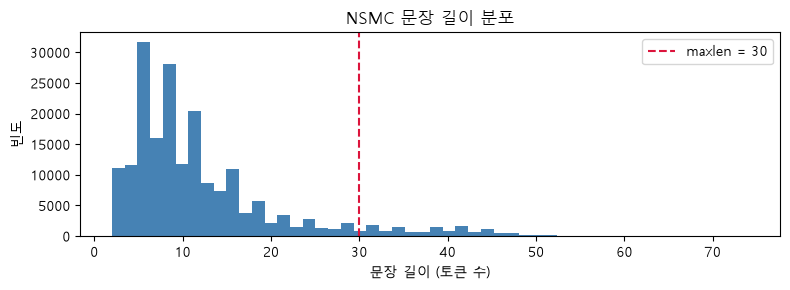

In [22]:
total_data_text = list(X_train) + list(X_test)
# 텍스트데이터 문장길이의 리스트를 생성한 후
num_tokens = [len(tokens) for tokens in total_data_text]
num_tokens = np.array(num_tokens)
# 문장길이의 평균값, 최대값, 표준편차
print('문장길이 평균 : ', np.mean(num_tokens))
print('문장길이 최대 : ', np.max(num_tokens))
print('문장길이 표준편차 : ', np.std(num_tokens))

# 최대 길이 = 평균 + 2*표준편차
max_tokens = np.mean(num_tokens) + 2 * np.std(num_tokens)
maxlen = int(max_tokens)
print('pad_sequences maxlen : ', maxlen)
print(f'전체 문장의 {np.sum(num_tokens < max_tokens) / len(num_tokens) * 100:.2f}%가 maxlen 설정값 이내에 포함됩니다.')

# 길이 분포 시각화
plt.figure(figsize=(8, 3))
plt.hist(num_tokens, bins=50, color='steelblue')
plt.axvline(maxlen, color='crimson', ls='--', label=f'maxlen = {maxlen}')
plt.xlabel('문장 길이 (토큰 수)')
plt.ylabel('빈도')
plt.title('NSMC 문장 길이 분포')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# Pre-padding 함수
# LSTM이 마지막 스텝의 hidden state을 쓰므로, 실제 토큰이 뒤쪽에 오도록 앞을 채웁니다.
def pad_sequences(data, maxlen, pad_value=0):
    padded_data = []
    for sentence in data:
        if len(sentence) < maxlen:
            sentence = [pad_value] * (maxlen - len(sentence)) + sentence
        else:
            # 길이를 초과하면 <BOS>는 남기고 뒤쪽(결론부)을 우선 보존
            sentence = [sentence[0]] + sentence[-(maxlen - 1):]
        padded_data.append(sentence)
    return np.array(padded_data)


X_train_padded = pad_sequences(X_train, maxlen, pad_value=word_to_index['<PAD>'])
X_test_padded = pad_sequences(X_test, maxlen, pad_value=word_to_index['<PAD>'])

print('X_train_padded :', X_train_padded.shape)
print('X_test_padded  :', X_test_padded.shape)
print(X_train_padded[0])

X_train_padded : (146060, 30)
X_test_padded  : (49117, 30)
[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   1  52 463  20 244 673]


## 4) 모델 구성 및 validation set 구성
---
모델은 3가지 이상 다양하게 구성하여 실험해 보세요.

In [25]:
# 학습 하이퍼파라미터 설정
VOCAB_SIZE = len(word_to_index)
WORD_VECTOR_DIM = 200      # ko.bin이 200차원이므로 동일하게 설정
PAD_IDX = word_to_index['<PAD>']

BATCH_SIZE = 128
EPOCHS = 15
LEARNING_RATE = 1e-3

# 체크포인트는 data/ 에 저장
CKPT_DIR = os.path.join(DATA_DIR, 'checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)

print(f'vocab {VOCAB_SIZE:,}, dim {WORD_VECTOR_DIM}, maxlen {maxlen}, batch {BATCH_SIZE}, epochs {EPOCHS}')

vocab 10,000, dim 200, maxlen 30, batch 128, epochs 15


In [26]:
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

# train을 8:2로 나눠 validation set 만듦
# stratify로 긍정/부정 비율을 train과 동일하게 유지
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_padded, y_train,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train,
)

print(f'train {len(X_tr):,} | val {len(X_val):,} | test {len(X_test_padded):,}')
print(f'긍정 비율 -> train {y_tr.mean():.4f} / val {y_val.mean():.4f} / test {y_test.mean():.4f}')


def make_loader(X, y, shuffle=False):
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.long),
        torch.tensor(y, dtype=torch.float32),
    )
    generator = torch.Generator().manual_seed(SEED) if shuffle else None
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        generator=generator,
        num_workers=0,
        pin_memory=True,
    )


train_loader = make_loader(X_tr, y_tr, shuffle=True)
val_loader = make_loader(X_val, y_val)
test_loader = make_loader(X_test_padded, y_test)

print(f'배치 수 -> train {len(train_loader)} / val {len(val_loader)} / test {len(test_loader)}')

train 116,848 | val 29,212 | test 49,117
긍정 비율 -> train 0.4983 / val 0.4984 / test 0.5027
배치 수 -> train 913 / val 229 / test 384


In [28]:
# 모델 1) LSTM
class LSTM(nn.Module):
    def __init__(self, vocab_size, word_vector_dim, hidden_size=64, padding_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, word_vector_dim, padding_idx=padding_idx)
        self.lstm = nn.LSTM(word_vector_dim, hidden_size, batch_first=True)
        # self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(hidden_size, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 1)   # 최종 출력은 긍정/부정을 나타내는 1dim

    def forward(self, x):
        x = self.embedding(x)
        lstm_out, (h_n, c_n) = self.lstm(x)
        x = h_n[-1]
        # x = self.dropout(x)
        x = self.relu(self.fc1(x))
        return self.fc2(x).squeeze(1)


print(LSTM(VOCAB_SIZE, WORD_VECTOR_DIM, padding_idx=PAD_IDX))

LSTM(
  (embedding): Embedding(10000, 200, padding_idx=0)
  (lstm): LSTM(200, 64, batch_first=True)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)


In [29]:
# 모델 2) TextCNN
class TextCNN(nn.Module):
    def __init__(self, vocab_size, word_vector_dim, num_filters=100, kernel_sizes=(3, 4, 5), padding_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, word_vector_dim, padding_idx=padding_idx)
        self.convs = nn.ModuleList([
            nn.Conv1d(word_vector_dim, num_filters, kernel_size=k) for k in kernel_sizes
        ])
        self.relu = nn.ReLU()
        # self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), 1)

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)
        feats = [self.relu(conv(x)).max(dim=2).values for conv in self.convs]   # 각각 (B, num_filters)
        x = torch.cat(feats, dim=1)
        # x = self.dropout(x)
        return self.fc(x).squeeze(1)


print(TextCNN(VOCAB_SIZE, WORD_VECTOR_DIM, padding_idx=PAD_IDX))

TextCNN(
  (embedding): Embedding(10000, 200, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(200, 100, kernel_size=(3,), stride=(1,))
    (1): Conv1d(200, 100, kernel_size=(4,), stride=(1,))
    (2): Conv1d(200, 100, kernel_size=(5,), stride=(1,))
  )
  (relu): ReLU()
  (fc): Linear(in_features=300, out_features=1, bias=True)
)


In [30]:
# 모델 3) MaxPoolMLP
class MaxPoolMLP(nn.Module):
    def __init__(self, vocab_size, word_vector_dim, hidden_size=64, padding_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, word_vector_dim, padding_idx=padding_idx)
        # self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(word_vector_dim, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, 1)   # 최종 출력은 긍정/부정을 나타내는 1dim

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)   # (B, dim, L)
        x = x.max(dim=2).values                  # global max pooling -> (B, dim)
        # x = self.dropout(x)
        x = self.relu(self.fc1(x))
        return self.fc2(x).squeeze(1)


print(MaxPoolMLP(VOCAB_SIZE, WORD_VECTOR_DIM, padding_idx=PAD_IDX))

MaxPoolMLP(
  (embedding): Embedding(10000, 200, padding_idx=0)
  (fc1): Linear(in_features=200, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)


## 5) 모델 훈련 개시
---
- 세 모델 모두 동일한 조건(같은 split, 동일 optimizer/lr/batch/epoch)으로 학습합니다.
- early stopping 없이 고정 epoch을 돌리되, `val_acc`가 가장 높았던 시점의 가중치를 복원해 test 평가에 사용합니다.

In [31]:
import copy


def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LEARNING_RATE, tag=''):
    """고정 epoch 동안 학습하고, val_acc가 가장 높았던 시점의 가중치를 복원해 반환합니다."""
    model = model.to(device)
    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses, train_accs = [], []
    val_losses, val_accs = [], []
    best_val_acc, best_epoch, best_state = 0.0, -1, None
    name = type(model).__name__ + tag

    for epoch in range(epochs):
        # ----- 학습 -----
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(inputs)              # logit (Sigmoid 이전 값)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)   # 배치 크기로 가중 -> 마지막 배치가 작아도 정확
            predicted = (outputs > 0).float()
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_losses.append(running_loss / total)
        train_accs.append(correct / total)

        # ----- 검증 -----
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = loss_fn(outputs, labels)

                val_loss += loss.item() * labels.size(0)
                predicted = (outputs > 0).float()
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_losses.append(val_loss / val_total)
        val_accs.append(val_correct / val_total)

        # ----- best 갱신 시에만 가중치 보관 (early stopping 없이 best만 챙김) -----
        if val_accs[-1] > best_val_acc:
            best_val_acc, best_epoch = val_accs[-1], epoch
            best_state = copy.deepcopy(model.state_dict())

        print(f'epoch {epoch + 1:2d} | train {train_losses[-1]:.4f}/{train_accs[-1]:.4f} '
              f'| val {val_losses[-1]:.4f}/{val_accs[-1]:.4f}'
              + ('  <- best' if best_epoch == epoch else ''))

    history = {'train_loss': train_losses, 'train_acc': train_accs,
               'val_loss': val_losses, 'val_acc': val_accs}

    model.load_state_dict(best_state)   # 최고 시점으로 복원한 뒤 평가에 사용
    torch.save(best_state, os.path.join(CKPT_DIR, f'best_{name}.pt'))
    print(f'[{name}] best epoch {best_epoch + 1} | val_acc {best_val_acc:.4f}')
    return model, history, best_epoch

In [32]:
def evaluate(model, loader):
    """test set 평가용"""
    model = model.to(device)
    model.eval()
    loss_fn = nn.BCEWithLogitsLoss()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = loss_fn(outputs, labels)

            total_loss += loss.item() * labels.size(0)
            predicted = (outputs > 0).float()
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total

In [33]:
import time

# 모델별 학습/테스트 결과를 모아둡니다.
# ! 이 셀을 다시 실행하면 기록이 비워지니 주의 !
results = {}

In [34]:
# ===== 모델 1) LSTM : 학습 =====
print('===== LSTM =====')

torch.manual_seed(SEED)   # 세 모델의 가중치 초기화 조건을 동일하게 맞춤
lstm_model = LSTM(VOCAB_SIZE, WORD_VECTOR_DIM, padding_idx=PAD_IDX)
lstm_params = sum(p.numel() for p in lstm_model.parameters())

started = time.time()
lstm_model, lstm_history, lstm_best_epoch = train_model(lstm_model, train_loader, val_loader)
lstm_elapsed = time.time() - started

# ===== 모델 1) LSTM : 테스트 =====
lstm_test_loss, lstm_test_acc = evaluate(lstm_model, test_loader)
print(f'\n[LSTM] test_loss {lstm_test_loss:.4f} | test_acc {lstm_test_acc:.4f} | 학습 {lstm_elapsed:.0f}초')

results['LSTM'] = {
    'model': lstm_model,
    'history': lstm_history,
    'best_epoch': lstm_best_epoch,
    'test_acc': lstm_test_acc,
    'params': lstm_params,
    'elapsed': lstm_elapsed,
}

===== LSTM =====
epoch  1 | train 0.4241/0.7998 | val 0.3561/0.8403  <- best
epoch  2 | train 0.3156/0.8632 | val 0.3423/0.8495  <- best
epoch  3 | train 0.2658/0.8884 | val 0.3417/0.8512  <- best
epoch  4 | train 0.2216/0.9100 | val 0.3682/0.8492
epoch  5 | train 0.1807/0.9286 | val 0.4022/0.8459
epoch  6 | train 0.1436/0.9452 | val 0.4521/0.8426
epoch  7 | train 0.1131/0.9576 | val 0.5534/0.8399
epoch  8 | train 0.0979/0.9646 | val 0.5853/0.8374
epoch  9 | train 0.0716/0.9734 | val 0.6892/0.8356
epoch 10 | train 0.0590/0.9783 | val 0.7490/0.8337
epoch 11 | train 0.0505/0.9814 | val 0.8329/0.8351
epoch 12 | train 0.0469/0.9826 | val 0.8974/0.8345
epoch 13 | train 0.0387/0.9857 | val 0.9692/0.8350
epoch 14 | train 0.0377/0.9860 | val 0.9879/0.8351
epoch 15 | train 0.0351/0.9870 | val 1.0021/0.8360
[LSTM] best epoch 3 | val_acc 0.8512

[LSTM] test_loss 0.3487 | test_acc 0.8497 | 학습 166초


In [35]:
# ===== 모델 2) TextCNN : 학습 =====
print('===== TextCNN =====')

torch.manual_seed(SEED)   # 세 모델의 가중치 초기화 조건을 동일하게 맞춤
cnn_model = TextCNN(VOCAB_SIZE, WORD_VECTOR_DIM, padding_idx=PAD_IDX)
cnn_params = sum(p.numel() for p in cnn_model.parameters())

started = time.time()
cnn_model, cnn_history, cnn_best_epoch = train_model(cnn_model, train_loader, val_loader)
cnn_elapsed = time.time() - started

# ===== 모델 2) TextCNN : 테스트 =====
cnn_test_loss, cnn_test_acc = evaluate(cnn_model, test_loader)
print(f'\n[TextCNN] test_loss {cnn_test_loss:.4f} | test_acc {cnn_test_acc:.4f} | 학습 {cnn_elapsed:.0f}초')

results['TextCNN'] = {
    'model': cnn_model,
    'history': cnn_history,
    'best_epoch': cnn_best_epoch,
    'test_acc': cnn_test_acc,
    'params': cnn_params,
    'elapsed': cnn_elapsed,
}

===== TextCNN =====
epoch  1 | train 0.4297/0.7957 | val 0.3678/0.8350  <- best
epoch  2 | train 0.2978/0.8741 | val 0.3691/0.8402  <- best
epoch  3 | train 0.2049/0.9202 | val 0.4065/0.8367
epoch  4 | train 0.1262/0.9553 | val 0.4713/0.8347
epoch  5 | train 0.0776/0.9735 | val 0.5319/0.8334
epoch  6 | train 0.0524/0.9831 | val 0.5985/0.8294
epoch  7 | train 0.0415/0.9859 | val 0.6736/0.8303
epoch  8 | train 0.0393/0.9861 | val 0.7501/0.8274
epoch  9 | train 0.0348/0.9881 | val 0.7905/0.8279
epoch 10 | train 0.0324/0.9889 | val 0.8682/0.8286
epoch 11 | train 0.0301/0.9897 | val 0.9287/0.8277
epoch 12 | train 0.0269/0.9906 | val 0.9130/0.8298
epoch 13 | train 0.0261/0.9905 | val 0.9620/0.8332
epoch 14 | train 0.0260/0.9911 | val 0.9848/0.8291
epoch 15 | train 0.0255/0.9911 | val 1.0091/0.8285
[TextCNN] best epoch 2 | val_acc 0.8402

[TextCNN] test_loss 0.3729 | test_acc 0.8374 | 학습 159초


In [36]:
# ===== 모델 3) MaxPoolMLP : 학습 =====
print('===== MaxPoolMLP =====')

torch.manual_seed(SEED)   # 세 모델의 가중치 초기화 조건을 동일하게 맞춤
mlp_model = MaxPoolMLP(VOCAB_SIZE, WORD_VECTOR_DIM, padding_idx=PAD_IDX)
mlp_params = sum(p.numel() for p in mlp_model.parameters())

started = time.time()
mlp_model, mlp_history, mlp_best_epoch = train_model(mlp_model, train_loader, val_loader)
mlp_elapsed = time.time() - started

# ===== 모델 3) MaxPoolMLP : 테스트 =====
mlp_test_loss, mlp_test_acc = evaluate(mlp_model, test_loader)
print(f'\n[MaxPoolMLP] test_loss {mlp_test_loss:.4f} | test_acc {mlp_test_acc:.4f} | 학습 {mlp_elapsed:.0f}초')

results['MaxPoolMLP'] = {
    'model': mlp_model,
    'history': mlp_history,
    'best_epoch': mlp_best_epoch,
    'test_acc': mlp_test_acc,
    'params': mlp_params,
    'elapsed': mlp_elapsed,
}

===== MaxPoolMLP =====
epoch  1 | train 0.5232/0.7297 | val 0.4316/0.7979  <- best
epoch  2 | train 0.3985/0.8185 | val 0.3916/0.8192  <- best
epoch  3 | train 0.3531/0.8445 | val 0.3825/0.8245  <- best
epoch  4 | train 0.3214/0.8619 | val 0.3719/0.8319  <- best
epoch  5 | train 0.2971/0.8751 | val 0.3721/0.8354  <- best
epoch  6 | train 0.2756/0.8861 | val 0.3839/0.8359  <- best
epoch  7 | train 0.2543/0.8978 | val 0.3834/0.8349
epoch  8 | train 0.2352/0.9071 | val 0.4086/0.8321
epoch  9 | train 0.2162/0.9166 | val 0.4056/0.8312
epoch 10 | train 0.1975/0.9253 | val 0.4405/0.8304
epoch 11 | train 0.1790/0.9344 | val 0.4452/0.8282
epoch 12 | train 0.1621/0.9419 | val 0.5378/0.8198
epoch 13 | train 0.1461/0.9488 | val 0.5454/0.8223
epoch 14 | train 0.1318/0.9542 | val 0.6109/0.8163
epoch 15 | train 0.1156/0.9609 | val 0.6239/0.8185
[MaxPoolMLP] best epoch 6 | val_acc 0.8359

[MaxPoolMLP] test_loss 0.3907 | test_acc 0.8340 | 학습 117초


In [38]:
# 세 모델 비교 요약
summary = pd.DataFrame([
    {
        '모델': name,
        'best epoch': r['best_epoch'] + 1,
        'best val_acc': round(max(r['history']['val_acc']), 4),
        'test_acc': round(r['test_acc'], 4),
        '학습 시간(초)': round(r['elapsed']),
    }
    for name, r in results.items()
]).sort_values('test_acc', ascending=False).reset_index(drop=True)

summary

,모델,best epoch,best val_acc,test_acc,학습 시간(초)
0,LSTM,3,0.8512,0.8497,166
1,TextCNN,2,0.8402,0.8374,159
2,MaxPoolMLP,6,0.8359,0.8340,117


## 6) Loss, Accuracy 그래프 시각화
---

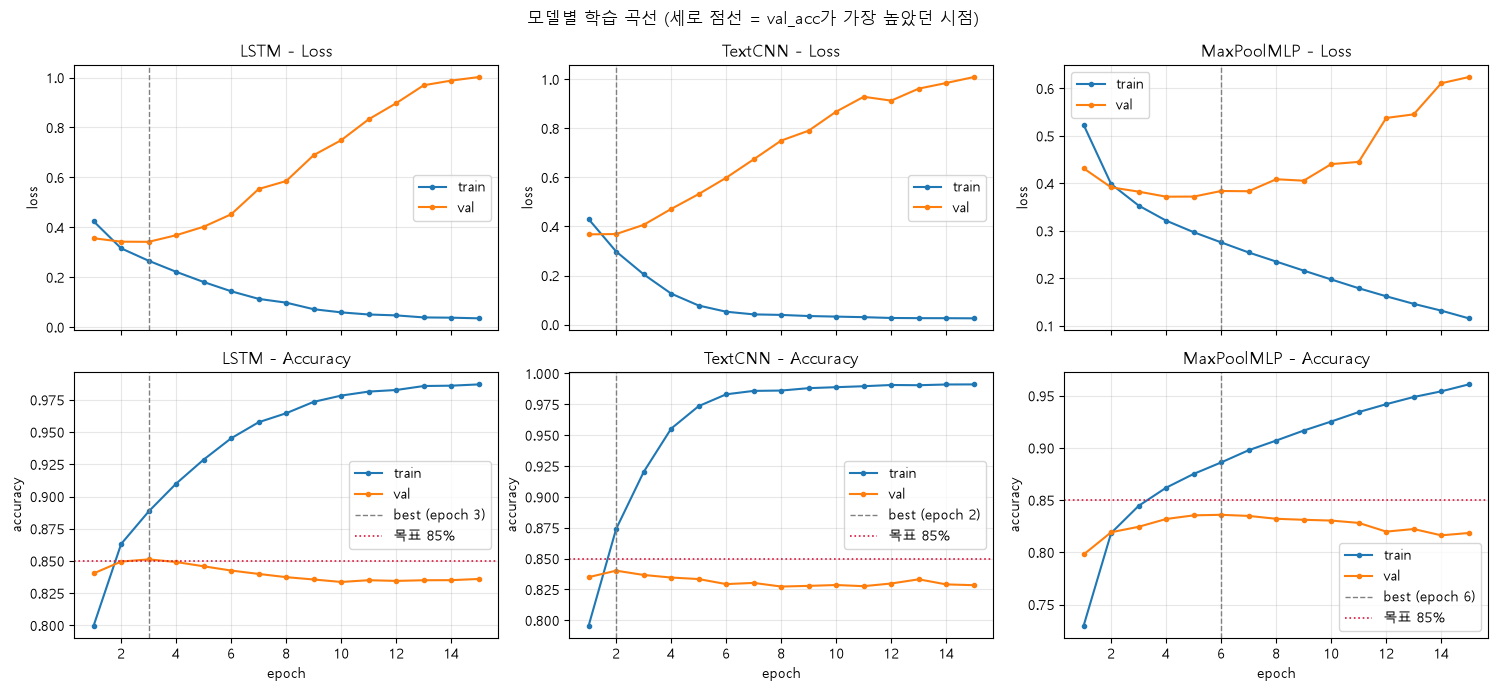

In [39]:
# 모델별 학습 곡선 (train vs val) - 과적합 시점을 확인합니다
model_names = [name for name in ['LSTM', 'TextCNN', 'MaxPoolMLP'] if name in results]

fig, axes = plt.subplots(2, len(model_names), figsize=(5 * len(model_names), 7), sharex=True)

for col, name in enumerate(model_names):
    history = results[name]['history']
    best = results[name]['best_epoch'] + 1
    epochs = range(1, len(history['train_loss']) + 1)

    # 위쪽 행: Loss
    ax = axes[0, col]
    ax.plot(epochs, history['train_loss'], 'o-', ms=3, label='train')
    ax.plot(epochs, history['val_loss'], 'o-', ms=3, label='val')
    ax.axvline(best, color='gray', ls='--', lw=1)
    ax.set_title(f'{name} - Loss')
    ax.set_ylabel('loss')
    ax.legend()
    ax.grid(alpha=0.3)

    # 아래쪽 행: Accuracy
    ax = axes[1, col]
    ax.plot(epochs, history['train_acc'], 'o-', ms=3, label='train')
    ax.plot(epochs, history['val_acc'], 'o-', ms=3, label='val')
    ax.axvline(best, color='gray', ls='--', lw=1, label=f'best (epoch {best})')
    ax.axhline(0.85, color='crimson', ls=':', lw=1.2, label='목표 85%')
    ax.set_title(f'{name} - Accuracy')
    ax.set_xlabel('epoch')
    ax.set_ylabel('accuracy')
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle('모델별 학습 곡선 (세로 점선 = val_acc가 가장 높았던 시점)')
fig.tight_layout()
plt.show()

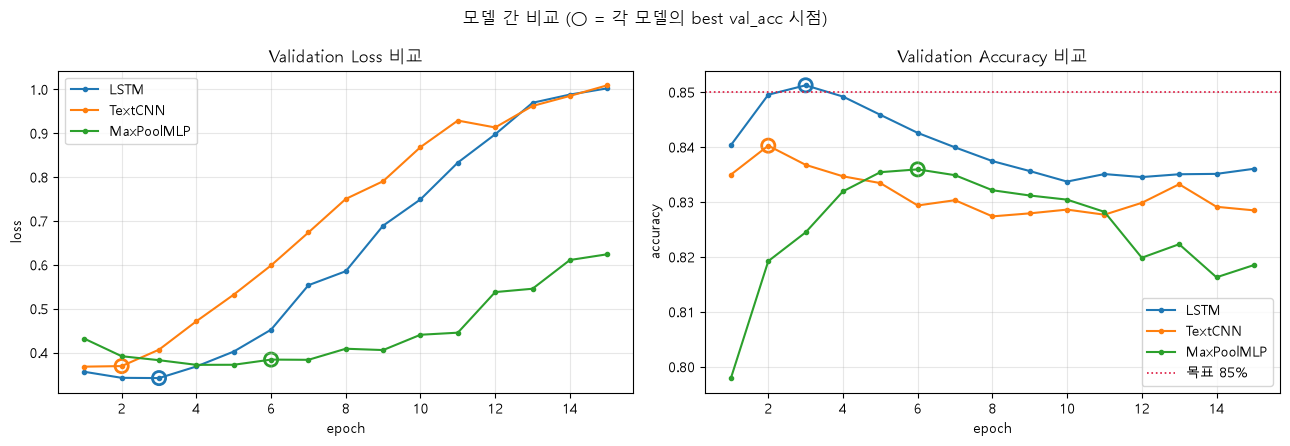

LSTM         best epoch  3 | best val_acc 0.8512 | test_acc 0.8497
TextCNN      best epoch  2 | best val_acc 0.8402 | test_acc 0.8374
MaxPoolMLP   best epoch  6 | best val_acc 0.8359 | test_acc 0.8340


In [40]:
# 세 모델의 validation 곡선을 한 그림에 겹쳐 직접 비교
model_names = [name for name in ['LSTM', 'TextCNN', 'MaxPoolMLP'] if name in results]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for name in model_names:
    history = results[name]['history']
    best_epoch = results[name]['best_epoch']
    epochs = range(1, len(history['val_loss']) + 1)

    line = axes[0].plot(epochs, history['val_loss'], 'o-', ms=3, label=name)[0]
    axes[0].scatter(best_epoch + 1, history['val_loss'][best_epoch],
                    s=90, facecolors='none', edgecolors=line.get_color(), linewidths=2)

    line = axes[1].plot(epochs, history['val_acc'], 'o-', ms=3, label=name)[0]
    axes[1].scatter(best_epoch + 1, history['val_acc'][best_epoch],
                    s=90, facecolors='none', edgecolors=line.get_color(), linewidths=2)

axes[0].set_title('Validation Loss 비교')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].axhline(0.85, color='crimson', ls=':', lw=1.2, label='목표 85%')
axes[1].set_title('Validation Accuracy 비교')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle('모델 간 비교 (○ = 각 모델의 best val_acc 시점)')
fig.tight_layout()
plt.show()

# 수렴 속도 / 최종 성능 정리
for name in model_names:
    r = results[name]
    print(f"{name:12s} best epoch {r['best_epoch'] + 1:2d} | "
          f"best val_acc {max(r['history']['val_acc']):.4f} | test_acc {r['test_acc']:.4f}")

## 7) 학습된 Embedding 레이어 분석
---
- 가장 성능이 좋았던 모델의 Embedding 레이어 가중치를 꺼내 gensim `KeyedVectors`로 변환합니다.
- `most_similar()`로 유사단어를 확인하고, 8)번의 사전학습 임베딩과 비교합니다.

## 8) 한국어 Word2Vec 임베딩 활용하여 성능 개선
---
- 한국어 Word2Vec은 /data 폴더 안에 있는 word2vec_ko.model을 활용하세요.
- 한국어 Word2Vec을 활용할 때는 `load_word2vec_format()` 형태가 아닌 `load()` 형태로 모델을 불러와주세요. 또한 모델을 활용할 때에는 아래 예시와 같이 `.wv`를 붙여서 활용합니다. 좀더 자세한 활용법에 대해선 다음 링크들을 참조해주세요. [참고 링크1](https://radimrehurek.com/gensim/auto_examples/tutorials/run_word2vec.html#storing-and-loading-models), [참고 링크2](https://radimrehurek.com/gensim/models/keyedvectors.html)

> **로컬 환경 메모:** AIFFEL이 제공하는 `word2vec_ko.model` 대신
> [Kyubyong/wordvectors](https://github.com/Kyubyong/wordvectors)의 한국어 모델(`data/ko/ko.bin`, 200차원)을 사용합니다.
> 셋업 셀의 `W2V_PATH`가 이 경로를 가리킵니다.
> 2016년에 만들어진 파일이라 gensim 4.x에서 로드가 실패할 수 있으니, 먼저 로드 테스트가 필요합니다.



```
# 예시 코드
from gensim.models.keyedvectors import Word2VecKeyedVectors
word_vectors = Word2VecKeyedVectors.load(word2vec_file_path)
vector = word_vectors.wv[‘끝’]
```

